In [136]:
from transformers import DetrForObjectDetection, DetrConfig, DetrImageProcessor, Trainer, TrainingArguments
from torch.utils.data import random_split
from dataset import DartsDataset
from torchvision import transforms
from PIL import Image, ImageDraw
import torch
from torchvision.datasets import CocoDetection
import numpy as np
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [137]:
id2label = {
    0: "right",
    1: "top",
    2: "left",
    3: "bottom",
    4: "dart",
}
label2id = {v: k for k, v in id2label.items()}

In [ ]:
model = DetrForObjectDetection.from_pretrained(
    "multi_res/checkpoint-3000", 
    auxiliary_loss=True, 
    num_queries=100,
    num_labels=5,  
    bbox_loss_coefficient=4.0,
    giou_loss_coefficient=1.0,
    giou_cost=0.0,
    eos_coefficient = 0.06,
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id,
)
image_processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50", size={"shortest_edge": 768, "longest_edge": 768})
image_processor

c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\Public\anaconda3\envs\darts\Lib\site-packages\torch\nn\modules\module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current 

DetrImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DetrImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "pad_size": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 768,
    "shortest_edge": 768
  }
}

In [139]:
dirs = [f'3D/scene/rendered/imgs_{i}' for i in range(6)]
dataset = DartsDataset(dirs=dirs)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
len(train_dataset), len(test_dataset)

(19200, 4800)

torch.Size([1, 3, 735, 735])
0
4
2
1
4
3


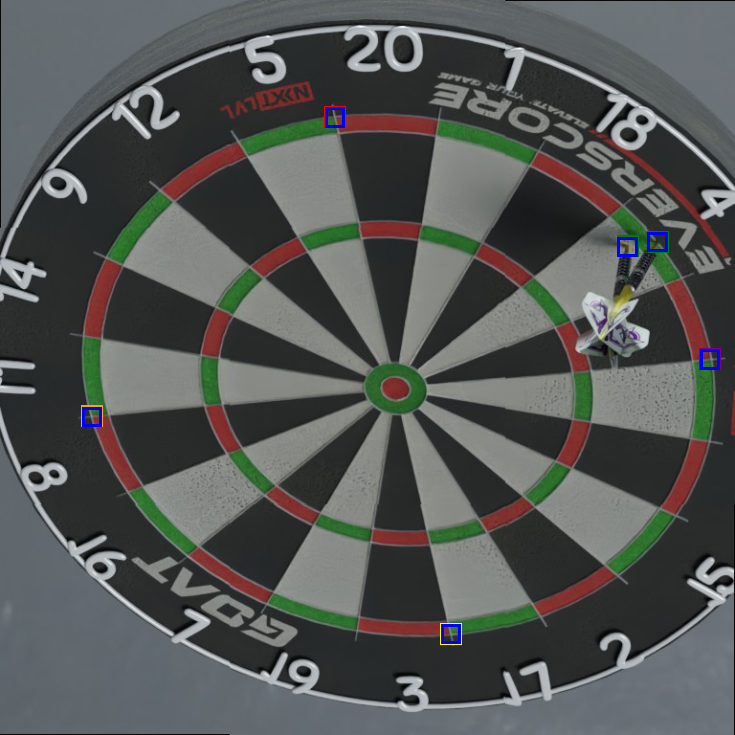

In [140]:
image, targets = test_dataset[np.random.randint(len(test_dataset))]
inputs = image_processor(images=image, annotations=targets, return_tensors="pt", do_resize=False)
print(inputs["pixel_values"].shape)
boxes = (inputs.labels[0].boxes*768).round()
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]
draw = ImageDraw.Draw(image)
for i, target in enumerate(targets["annotations"]):
    box, category_id = target["bbox"], target["category_id"]
    x, y, w, h = box
    box = [x, y, x + w , y + h]
    color = ["purple", "red", "orange", "yellow", "green"]
    draw.rectangle(box, outline=color[min(i, len(color)-1)], width=3)
for i, box in enumerate(results["boxes"]):
    label= results["labels"][i].item()
    print(label)
    draw.rectangle(box.tolist(), outline="blue", width=3)
image

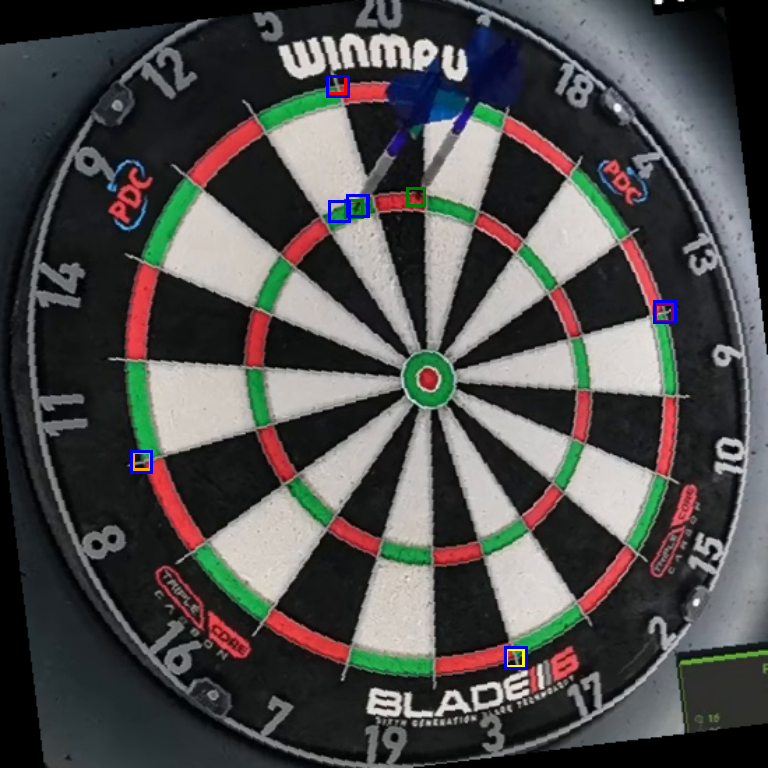

In [153]:
dirs = [f'my_unlabelled/vids/frames_000{i}' for i in range(8)]
val_dataset = DartsDataset(dirs=dirs, resize_to=768, random_rescale=False)

index = np.random.randint(len(val_dataset))
image, targets = val_dataset[index]
# image = Image.open("thommy/_IMG0813.jpg")
inputs = image_processor(images=image, annotations=targets, return_tensors="pt")

boxes = (inputs.labels[0].boxes*768).round()
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]
draw = ImageDraw.Draw(image)
for i, target in enumerate(targets["annotations"]):
    box, category_id = target["bbox"], target["category_id"]
    x, y, w, h = box
    box = [x, y, x + w , y + h]
    color = ["purple", "red", "orange", "yellow", "green"]
    draw.rectangle(box, outline=color[min(i, len(color)-1)], width=3)
for i, box in enumerate(results["boxes"]):
    label= results["labels"][i].item()
    draw.rectangle(box.tolist(), outline="blue", width=3)
image